In [1]:
# Step 1: Install packages (if needed)
!pip install pandas scikit-learn matplotlib seaborn shap --quiet


In [2]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

import shap  # for explainability


In [3]:
# Step 3: Upload and load the dataset
from google.colab import files
uploaded = files.upload()

# Load the dataset (assuming it's a CSV)
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving shopping_data.zip to shopping_data (1).zip


,Unnamed: 0,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,0,1,55,Male,Blouse,Clothing,53,Kentucky,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,1,2,19,Male,Sweater,Clothing,64,Maine,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,2,3,50,Male,Jeans,Clothing,73,Massachusetts,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,3,4,21,Male,Sandals,Footwear,90,Rhode Island,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,4,5,45,Male,Blouse,Clothing,49,Oregon,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# ✅ Step 4: Define the target variable (Frequent Buyer)
df['Frequent_Buyer'] = df['Frequency of Purchases'].apply(
    lambda x: 1 if x in ['Weekly', 'Fortnightly'] else 0
)

df['Frequent_Buyer'].value_counts()mb

,count
Frequent_Buyer,
0,2819
1,1081


In [5]:
# Drop irrelevant or leaking columns
df = df.drop(columns=[
    'Unnamed: 0',
    'Customer ID',
    'Item Purchased',
    'Purchase Amount (USD)',
    'Frequency of Purchases'
])


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode all object (categorical) columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

df.head()


,Age,Gender,Category,Location,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequent_Buyer
0,55,1,1,16,7,3,3.1,1,1,1,1,14,5,1
1,19,1,1,18,12,3,3.1,1,1,1,1,2,1,1
2,50,1,1,20,12,1,3.1,1,2,1,1,23,2,1
3,21,1,2,38,12,1,3.5,1,3,1,1,49,4,1
4,45,1,1,36,21,1,2.7,1,2,1,1,31,4,0


from matplotlib import pyplot as plt
_df_0['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Category'].plot(kind='hist', bins=20, title='Category')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Location'].plot(kind='hist', bins=20, title='Location')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Color'].plot(kind='hist', bins=20, title='Color')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Gender']
  ys = series['Season']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('Gender', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Gender')
_ = plt.ylabel('Season')

from matplotlib import pyplot as plt
_df_12['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Category'].plot(kind='line', figsize=(8, 4), title='Category')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Location'].plot(kind='line', figsize=(8, 4), title='Location')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['Color'].plot(kind='line', figsize=(8, 4), title='Color')
plt.gca().spines[['top', 'right']].set_visible(False)

In [7]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop(columns=['Frequent_Buyer'])
y = df['Frequent_Buyer']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((3120, 13), (780, 13))

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize models
logreg = LogisticRegression(max_iter=1000)
dtree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# Train models
logreg.fit(X_train, y_train)
dtree.fit(X_train, y_train)
knn.fit(X_train, y_train)

# Predict on test set
logreg_pred = logreg.predict(X_test)
dtree_pred = dtree.predict(X_test)
knn_pred = knn.predict(X_test)

# Evaluate
print(" Logistic Regression:\n", classification_report(y_test, logreg_pred))
print(" Decision Tree:\n", classification_report(y_test, dtree_pred))
print(" k-NN:\n", classification_report(y_test, knn_pred))


 Logistic Regression:
               precision    recall  f1-score   support

           0       0.73      1.00      0.85       572
           1       0.00      0.00      0.00       208

    accuracy                           0.73       780
   macro avg       0.37      0.50      0.42       780
weighted avg       0.54      0.73      0.62       780

 Decision Tree:
               precision    recall  f1-score   support

           0       0.75      0.70      0.72       572
           1       0.30      0.34      0.32       208

    accuracy                           0.61       780
   macro avg       0.52      0.52      0.52       780
weighted avg       0.63      0.61      0.62       780

 k-NN:
               precision    recall  f1-score   support

           0       0.73      0.85      0.78       572
           1       0.22      0.12      0.16       208

    accuracy                           0.65       780
   macro avg       0.47      0.48      0.47       780
weighted avg       0.59   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
# Balanced Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg_bal = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_bal.fit(X_train, y_train)

# Predictions
logreg_pred_bal = logreg_bal.predict(X_test)

# Evaluation
print("🔷 Balanced Logistic Regression:\n", classification_report(y_test, logreg_pred_bal))


🔷 Balanced Logistic Regression:
               precision    recall  f1-score   support

           0       0.72      0.50      0.59       572
           1       0.26      0.48      0.33       208

    accuracy                           0.49       780
   macro avg       0.49      0.49      0.46       780
weighted avg       0.60      0.49      0.52       780



In [10]:
# Balanced Decision Tree
from sklearn.tree import DecisionTreeClassifier

dtree_bal = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dtree_bal.fit(X_train, y_train)

dtree_pred_bal = dtree_bal.predict(X_test)

print("🌳 Balanced Decision Tree:\n", classification_report(y_test, dtree_pred_bal))


🌳 Balanced Decision Tree:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76       572
           1       0.31      0.28      0.30       208

    accuracy                           0.64       780
   macro avg       0.53      0.53      0.53       780
weighted avg       0.63      0.64      0.64       780



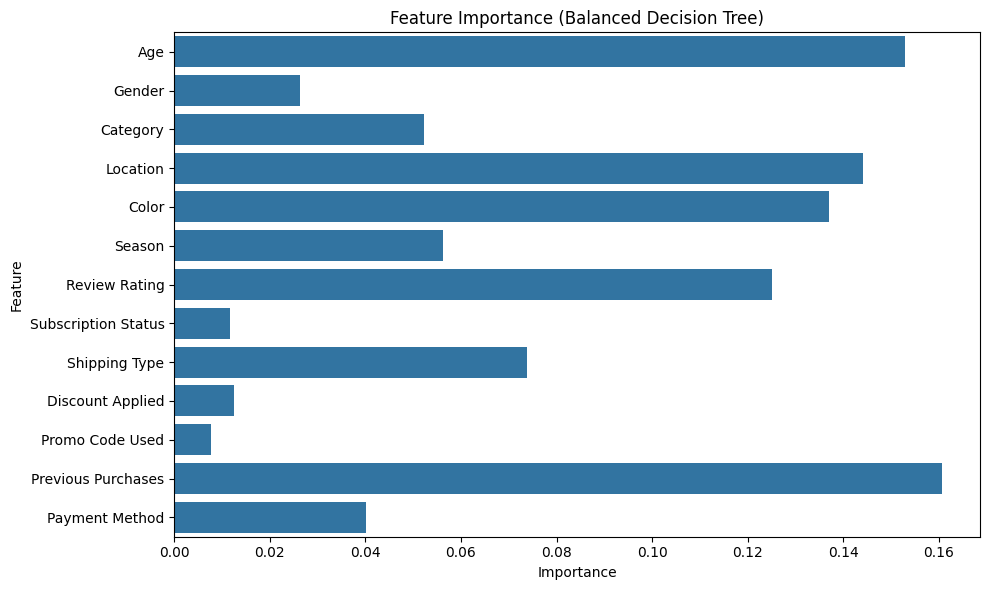

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importances
importances = dtree_bal.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title('Feature Importance (Balanced Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [12]:
!pip install shap


In [18]:
import shap

# Step 1: Initialize TreeExplainer with your correct model
explainer = shap.TreeExplainer(dtree_bal)

# Step 2: Compute SHAP values for the test data
shap_values = explainer.shap_values(X_test)





In [25]:
import pandas as pd
import shap

# If you used something like OneHotEncoder or pd.get_dummies earlier
# Re-create the column names exactly from X_train
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

# SHAP explainer
explainer = shap.TreeExplainer(dtree_bal)
shap_values = explainer.shap_values(X_test_df)




In [24]:
print("shap_values[1] shape:", shap_values[1].shape)
print("X_test shape:", X_test.shape)
print("X_train shape:", X_train.shape)
print("X_test_df shape:", X_test_df.shape)


shap_values[1] shape: (13, 2)
X_test shape: (780, 13)
X_train shape: (3120, 13)
X_test_df shape: (780, 13)
